---
title: "Single-Cell Preprocessing"
author: 
  - "Maximilian Nuber" 
  - "Junyan Lu"
format: 
  html: 
    page-layout: full
    code-fold: false        # fold all executable code blocks
    code-summary: "Show code"   # text on the disclosure widget (optional)
    code-tools: true       # optional: global "Show/Hide All Code" menu
    toc: true
    number-sections: true
    number-depth: 3
    theme: book.scss
    embed-resources: true
execute:
  echo: true               # code is present, so it can be folded
  warning: false           # still suppress warnings
  message: false           # suppress messages
---


At this point, you will have heard the basic steps of single cell processing in the lecture:

1. Normalization
2. Calculating highly variable genes
3. Dimensionality Reduction (DR)
4. UMAP for visualization (based on DR)
5. Clustering (based on DR)
6. Marker Detection

We will first use the `scanpy` package for processing a single.

As an example for using conda, see  `conda_envs/lecture__processing.yaml`, and run the command:

```conda env create -f /path/to/lecture__processing.yaml```

Otherwise, we are using the uv-environment. For installing the env, open a terminal, go into directory `01_single_cell_processing` where you find the `pyproject.toml`-file, and type `uv sync`. Done.

In [1]:
# First we import required packages:

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1. Preparing the Data for Comparison

Before we can identify cell types or find marker genes, we have to account for the fact that some cells simply capture more RNA than others due to technical noise (sequencing depth).

In [2]:
# We load a dataset from the scanpy package, just some blood cells from a healthy donor:

adata = sc.datasets.pbmc3k()

# The normalization in scanpy was divided into two functions:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

Why are we doing this?

- Normalization (normalize_total): In a single-cell experiment, one cell might have 5,000 detected transcripts while another has 15,000. If we don't normalize, the second cell will look like it has "more" of every gene simply because it was sequenced deeper. This step scales every cell to a common total (10,000), allowing for an "apples-to-apples" comparison.

- Log Transformation (log1p): Gene expression data is often "skewed"—a few highly expressed genes can have counts in the thousands, while most have counts of 1 or 2.

    The log transform squashes this scale so that a change from 10 to 100 counts is weighted similarly to a change from 1,000 to 10,000.

    We use log1p, which calculates log(1+x), because we cannot take the log of zero (and single-cell data has a lot of zeros).

The Bottom Line: These steps ensure that the differences we see later are driven by biology (cell type differences) rather than technology (how well the sequencer ran that day).

2. Identifying Biological "Signal"

Now that the data is normalized, we need to decide which genes are actually worth looking at and simplify the data so we can eventually group (cluster) the cells.

In [3]:
# 1. Identify the top 2,000 "Highly Variable Genes" (HVGs)
# These are genes that vary significantly across different cells, 
# suggesting they are biological markers rather than just noise.
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

# 2. Run Principal Component Analysis (PCA)
# This compresses the 2,000 genes into 50 "Principal Components" (meta-genes).
# It captures the most important patterns while ignoring random technical variation.
sc.pp.pca(adata, n_comps=50, use_highly_variable=True)

/tmp/ipykernel_166652/242887882.py:9: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.pp.pca(adata, n_comps=50, use_highly_variable=True)


Why are we doing this?

- Highly Variable Genes (highly_variable_genes): * If a gene is expressed at exactly the same level in every single cell, it doesn't help us distinguish a T-cell from a B-cell.

    We filter for genes that show high variance (high "peaks" and low "valleys" across the dataset). By focusing on the top 2,000 genes, we strip away thousands of uninformative data points, making the analysis much faster and cleaner.

- PCA (pca): * Even with 2,000 genes, the data is too "big" to visualize or cluster easily.

    PCA is a mathematical trick that creates Principal Components (PCs). You can think of a PC as a "meta-gene" that represents a group of genes that usually go up or down together.

    Instead of looking at 2,000 separate dimensions, we look at the top 50 PCs which usually contain almost all the biological information we need.

The Bottom Line: We are throwing away the "background noise" (genes that don't change) and then summarizing the remaining "signal" into a manageable format for the computer to process.

3. Determining the "Elbow" (Selecting PCs)

Before moving to clustering, we look at how much information (variance) each Principal Component contributes. We want to keep the PCs that explain a lot and discard the ones that contribute very little.

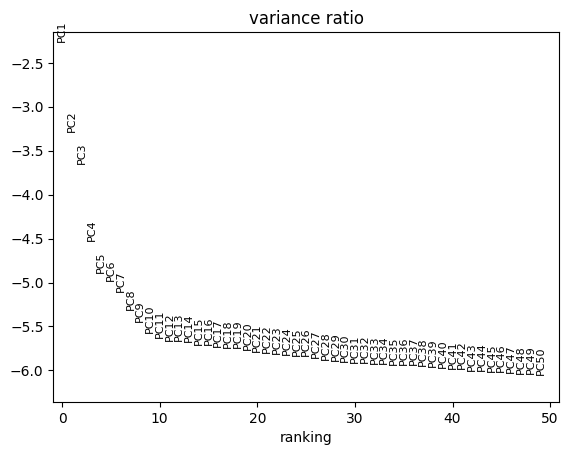

In [4]:
# 1. Visualize the "Variance Ratio" for the first 50 PCs
# This generates an "Elbow Plot" to show the importance of each PC.
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

# 2. Downstream, we will use the first 30 PCs.
# These 30 components capture the vast majority of the biological 
# "story" (50% of the total variance) while leaving out technical noise.

Why are we doing this?

- The Law of Diminishing Returns: PC1 explains the most variation (e.g., the difference between a lymphocyte and a myeloid cell). PC2 explains the next most, and so on. 
    By the time you get to PC40 or PC50, the "information" they add is usually just random technical noise or very minor batch effects.

- The "Elbow" Method: Biologists look at this plot for a "bend" or "elbow." The point where the curve starts to flatten out is where the computer has run out of major biological patterns to find.

- Why 30? Choosing 30 is a common "safe" middle ground for PBMC data. It’s enough to capture subtle cell subtypes (like different flavors of T-cells) without including so many PCs that the analysis becomes "muddy" with noise.

The Bottom Line: We are narrowing our focus from 2,000 genes to 30 "patterns." This makes the next step—grouping cells into clusters—much more accurate and computationally efficient.

4. Mapping the Cellular Landscape

Now that we have our 30 Principal Components, we use them to figure out which cells are "neighbors" and group them into distinct clusters (communities).

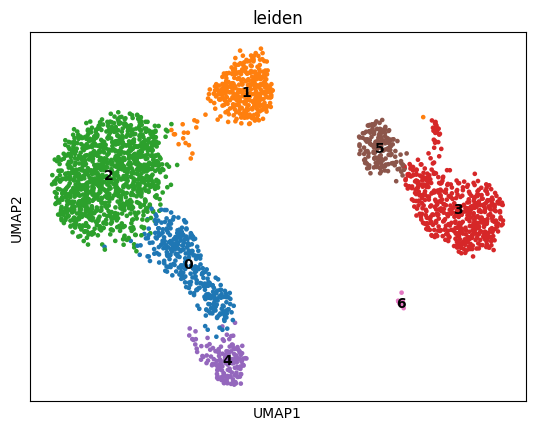

In [5]:
# 1. Build a neighborhood graph
# For every cell, find its 30 nearest "friends" based on similarity.
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30)

# 2. Calculate UMAP (Uniform Manifold Approximation and Projection)
# This flattens the complex multidimensional data into a 2D map for our eyes.
sc.tl.umap(adata)

# 3. Cluster the cells using the "Leiden" algorithm
# This identifies communities of cells that are highly connected to each other.
# 'resolution' controls how granular the clusters are (higher = more clusters).
sc.tl.leiden(adata, resolution=0.5, flavor="igraph")

# 4. Plot the results
# Visualize the UMAP and color the cells by their Leiden cluster identity.
sc.pl.umap(adata, color=["leiden"], legend_loc="on data")

Why are we doing this?

- Nearest Neighbors (neighbors): Imagine a social network. This step looks at our 30 "meta-genes" and decides which cells are most similar to each other. It builds a web (a graph) where lines connect cells that share a similar profile.

- UMAP (umap): High-dimensional data is impossible for humans to visualize. UMAP is a sophisticated "map-maker" that takes that complex web of connections and lays it out on a 2-D plot. It tries to keep similar cells close together and different cells far apart.

- Leiden Clustering (leiden): While UMAP shows us the groups, Leiden is what actually labels them. It treats the neighbors graph like a city and looks for neighborhoods.

    Resolution: This is the "zoom" level. A low resolution (0.1) might group all T-cells together, while a higher resolution (1.0) might split them into CD4+ and CD8+ subtypes.

The Bottom Line: We’ve gone from a raw count matrix to a biological map. Each colorful "blob" on your UMAP now represents a group of cells that share a similar transcriptional program—likely representing specific cell types like B-cells, T-cells, or Monocytes.

`scanpy` uses the famous scikit-learn library under the hood, which is made by general purpose data scientists, and scales very well to larger datasets. However, other normalizations may be more suitable, depending on your dataset:

/tmp/ipykernel_166652/3597580367.py:5: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.pp.pca(adata, n_comps=50, use_highly_variable=True)


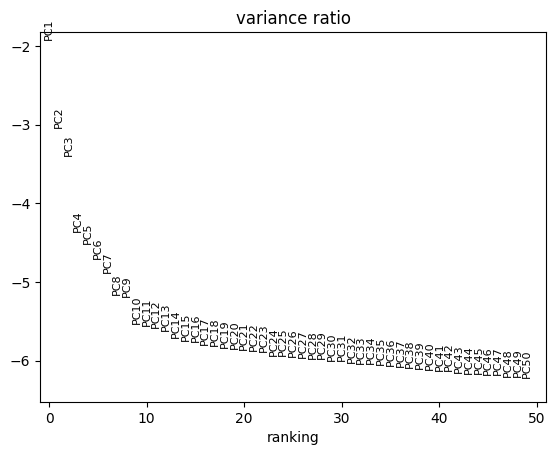

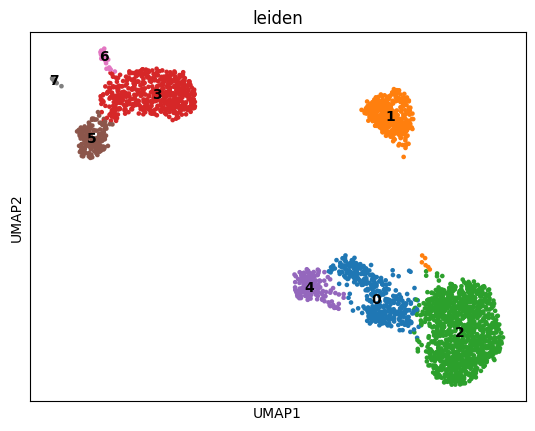

In [6]:
adata = sc.datasets.pbmc3k()
sc.pp.normalize_total(adata, target_sum=None) # Median normalization
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.pp.pca(adata, n_comps=50, use_highly_variable=True)
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5, flavor="igraph")
sc.pl.umap(adata, color=["leiden"], legend_loc="on data")

Or we use the normalization made canonical by Bioconductor (now available in Python):

/tmp/ipykernel_166652/4202069553.py:17: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.pp.pca(adata, n_comps=50, use_highly_variable=True)


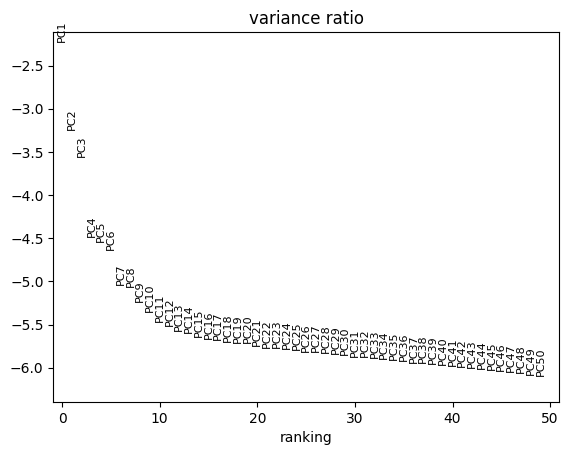

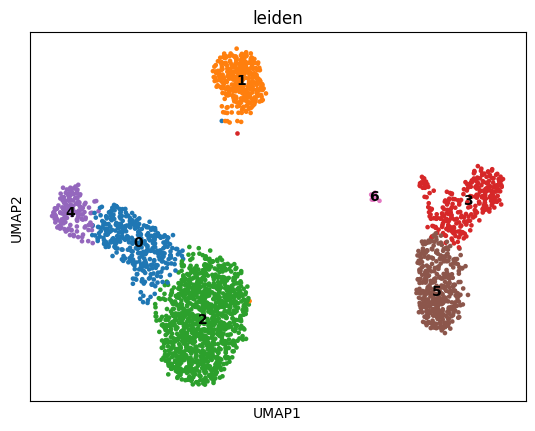

In [7]:
import scranpy

adata = sc.datasets.pbmc3k()

mat = adata.X.T

size_factors = scranpy.center_size_factors(mat.sum(0).A1)
normalized = scranpy.normalize_counts(
    mat, 
    size_factors=size_factors, 
    delayed=False)

adata.layers["counts"] = adata.X.copy() # so we keep un-normalized counts
adata.X = normalized.tocsc().T

sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.pp.pca(adata, n_comps=50, use_highly_variable=True)
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5, flavor="igraph")
sc.pl.umap(adata, color=["leiden"], legend_loc="on data")

5. Identifying Marker Genes (Cell Type Annotation)

To figure out what these clusters actually are, we ask the computer: "Which genes are significantly higher in Cluster X than in the rest of the dataset?"

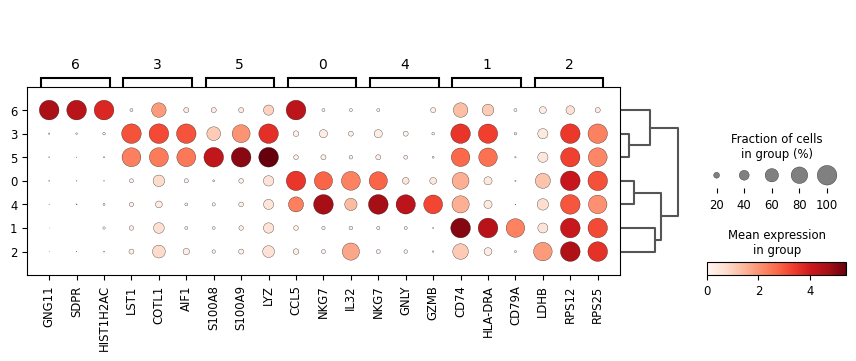

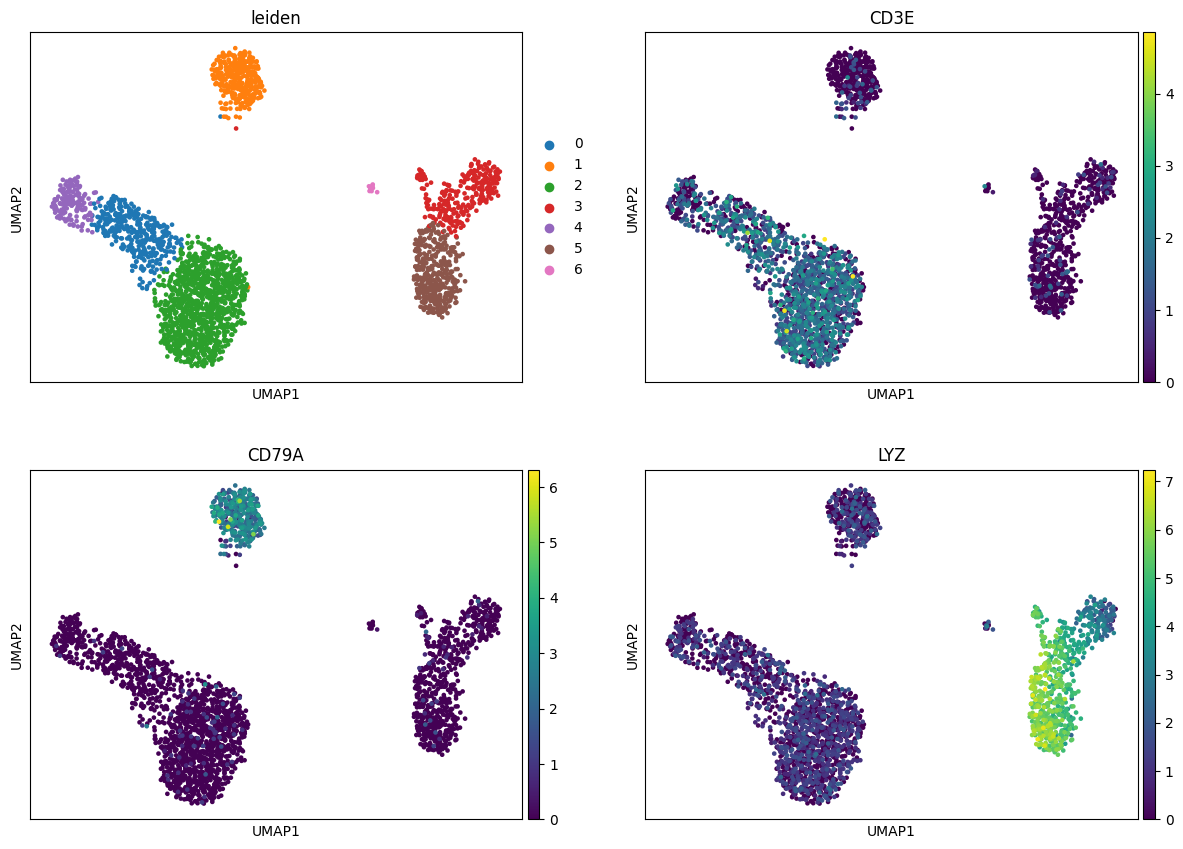

In [9]:
# 1. Statistical test to find markers for each cluster
# This compares each cluster against all other clusters (One-vs-All).
# We use 'wilcoxon', which is a standard, robust statistical test.
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')

# 2. Visualize the top 3 markers for each cluster in a Dot Plot
# This shows both how many cells express the gene (dot size) 
# and how strongly they express it (color intensity).
sc.pl.rank_genes_groups_dotplot(adata, n_genes=3)

# 3. Validation: Plot known canonical markers on the UMAP
# Let's check for T cells (CD3E), B cells (CD79A), and Monocytes (LYZ).
sc.pl.umap(adata, color=['leiden', 'CD3E', 'CD79A', 'LYZ'], ncols = 2)

Why are we doing this?

- Ranking Genes (rank_genes_groups): This is essentially doing thousands of mini "t-tests" (or Wilcoxon tests). If CD3E is at the top of the list for Cluster 0, and you know CD3 is a T-cell marker, you’ve just identified your T-cell population.

- The Dot Plot (rank_genes_groups_dotplot): This is the "gold standard" visualization for marker genes.

    Dot Size: Represents the percentage of cells in that cluster expressing the gene (e.g., "Is this gene in all my T-cells or just a few?").

    Color Intensity: Represents the average expression level (e.g., "How 'bright' is this gene?").

- Ground Truthing (umap with gene names): Even if the computer suggests markers, biologists usually have a "shortlist" of favorite genes they trust. Plotting these known markers directly onto the UMAP allows you to confirm that the clusters make biological sense.

The Bottom Line: We use statistics to find "unbiased" markers, then use our "biased" biological knowledge to assign real names (like "Cytotoxic T-cell" or "Mature B-cell") to the numerical clusters.